# DLW 数值分析 report

以 DLW 单孤子与二孤子的解析解为参照，比较 SD、SD2 与 FD，以及固定网格与动网格。SD 直接推进双线性方程，采用隐式中点；SD2、FD 比较 Euler 与 RK4。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.interpolate import CubicSpline
from scipy.sparse import bmat, csc_matrix, coo_matrix, diags
from scipy.sparse.linalg import splu
from IPython.display import display

plt.rcParams.update({'font.family': 'DejaVu Serif', 'font.size': 11,
    'axes.linewidth': .7, 'axes.spines.top': False,
    'axes.spines.right': False, 'xtick.direction': 'in',
    'ytick.direction': 'in', 'figure.dpi': 110})

## 1　模型与实验设计

连续 DLW 方程为

$$\begin{aligned}
u_{yt}&=-\partial_x[(u+2a)u_y]-v_{xx},\\
v_t&=-\partial_x[(u+2a)v-4u]-u_{xxy}.
\end{aligned}$$

采用 Sheng–Yu 原文的三组孤子参数，$a=2$、$c_i=1$，初相位为零。A、B 分别对应图 1(a)、1(b)，C 对应图 3；具体 $p_i,q_i$ 如下表。取 $\Delta t=0.000125$、$T=0.01$。

In [2]:
CASES = {'A': ((1.,), (2.,)), 'B': ((4.,), (-3.,)),
         'C': ((6., 4.), (-5., -3.))}
CONFIG = dict(a=2., nx=256, L=40., h=.125, dt=.000125, T=.01,
              yhalf=1.5, eval_half=10., eval_points=4001)
MODELS = ('SD', 'SD2', 'FD')
COLORS = dict(SD='#1776bc', SD2='#d47b19', FD='#38965f')
pd.DataFrame([{'算例': k, 'p': p, 'q': q} for k, (p, q) in CASES.items()])

,算例,p,q
0,A,"(1.0,)","(2.0,)"
1,B,"(4.0,)","(-3.0,)"
2,C,"(6.0, 4.0)","(-5.0, -3.0)"


### 1.1　孤子参照

记 $S_i=p_i+q_i$、$\omega_i=q_i^2-p_i^2$、$\ell_i=(p_i-a)^{-1}+(q_i+a)^{-1}$，并令 $\theta_i=S_ix+\omega_it+\ell_i y$。单孤子的 $g=1+e^{\theta_1}/S_1$；二孤子的

$$g=1+\frac{e^{\theta_1}}{S_1}+\frac{e^{\theta_2}}{S_2}
+\frac{(p_1-p_2)(q_1-q_2)e^{\theta_1+\theta_2}}
{(p_1+q_1)(p_1+q_2)(p_2+q_1)(p_2+q_2)}.$$

$f$ 在各指数项中加入因子 $\gamma_i=-(p_i-a)/(q_i+a)$。物理场取

$$u_*=2\partial_x(\log f-\log g),\qquad
v_*=2\partial_x\partial_y(\log f+\log g).$$

用对数和计算正系数 tau 函数；对数的一阶、二阶导数分别是指数率的加权均值、协方差。

In [3]:
class Exact:
    def __init__(self, case, h, a=2.):
        p, q = map(np.asarray, CASES[case])
        self.h = h
        s, omega, ell = p+q, q*q-p*p, 1/(p-a)+1/(q+a)
        gamma = np.log(-(p-a)/(q+a))
        if len(p) == 1:
            self.coeff = np.array([1., 1/s[0]])
            subsets = np.array([[0.], [1.]])
        else:
            cross = ((p[0]-p[1])*(q[0]-q[1]) /
                ((p[0]+q[0])*(p[0]+q[1])*(p[1]+q[0])*(p[1]+q[1])))
            self.coeff = np.array([1., 1/s[0], 1/s[1], cross])
            subsets = np.array([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])
        self.rates = subsets @ np.stack((s, omega, ell), axis=1)
        self.gamma = subsets @ gamma
        self._key, self._cache = None, {}

    def tau(self, js, x, t, is_f=False):
        y = (np.atleast_1d(js)+.5)*self.h
        logs = (np.log(self.coeff)[:, None, None]
            + self.rates[:, 0, None, None]*np.atleast_1d(x)[None, None, :]
            + self.rates[:, 1, None, None]*t
            + self.rates[:, 2, None, None]*y[None, :, None])
        if is_f:
            logs = logs + self.gamma[:, None, None]
        total = logsumexp(logs, axis=0)
        return total, np.exp(logs-total[None, :, :])

    def mean(self, w, k):
        return np.einsum('i,ijk->jk', self.rates[:, k], w)

    def cov(self, w, a, b):
        return (np.einsum('i,ijk->jk', self.rates[:, a]*self.rates[:, b], w)
                - self.mean(w, a)*self.mean(w, b))

    def uv(self, js, x, t):
        key = (float(t), np.asarray(x).tobytes())
        if key != self._key:
            self._key, self._cache = key, {}
        sub = tuple(np.atleast_1d(js))
        if sub not in self._cache:
            _, f = self.tau(js, x, t, True)
            _, g = self.tau(js, x, t)
            self._cache[sub] = (2*(self.mean(f, 0)-self.mean(g, 0)),
                2*(self.cov(f, 0, 2)+self.cov(g, 0, 2)))
        return tuple(v.copy() for v in self._cache[sub])

## 2　空间离散与边界

$x\in[-20,20)$ 分为 256 份，$\Delta x=0.15625$；$y\in[-1.5,1.5]$ 分为 24 份，$h=0.125$，场值取各份中点。

记 $\delta_-f_j=(f_j-f_{j-1})/h$、$\delta_0f_j=(f_{j+1}-f_{j-1})/(2h)$、$M_-f_j=(f_j+f_{j-1})/2$。$x$ 向差分为

$$D_1f_i=\frac{f_{i-2}-8f_{i-1}+8f_{i+1}-f_{i+2}}{12\Delta x},\qquad D_2f=D_1(D_1f).$$

SD 固定两端各四个节点的解析边界值；SD2 按端点跃变量延拓，FD 按周期延拓。各方案的下边界在本节对应部分给出。

In [4]:
class Grid:
    def __init__(self, n, L):
        self.n, self.L, self.dx = n, L, L/n
        self.xi = -L/2 + np.arange(n)*self.dx
        self.set_s(np.zeros(n))

    def dxi(self, f):
        return (np.roll(f, 2, axis=-1)-8*np.roll(f, 1, axis=-1)
            +8*np.roll(f, -1, axis=-1)-np.roll(f, -2, axis=-1))/(12*self.dx)

    def set_s(self, s):
        self.s = np.asarray(s).copy()
        self.x, self.J = self.xi+self.s, 1+self.dxi(self.s)
        if self.J.min() <= 0 or np.diff(np.r_[self.x, self.x[0]+self.L]).min() <= 0:
            raise ValueError('网格 Jacobian 非正或节点交叉')

    def d1(self, f):
        return self.dxi(f)/self.J

    def d2(self, f):
        return self.d1(self.d1(f))

def delta0(u, ghosts, h):
    ext = np.concatenate((ghosts[0][None, :], u, ghosts[1][None, :]))
    return (ext[2:]-ext[:-2])/(2*h)

def ghost_u(G, js, x, t, u):
    gl, gr = G.uv([js[0]-1, js[-1]+1], x, t)[0]
    # 上侧外推扰动；解析背景与内部数值解分开处理。
    e = u[-3:]-G.uv(js[-3:], x, t)[0]
    return gl, gr+3*e[-1]-3*e[-2]+e[-3]

In [5]:
class PhysicalModel:
    def __init__(self, case, model, config):
        self.kind, self.h, self.a = model, config['h'], config['a']
        self.X = Grid(config['nx'], config['L'])
        self.G = Exact(case, self.h, self.a)
        n = round(config['yhalf']/self.h)
        self.js = np.arange(-n, n)
        self.y = (self.js+.5)*self.h
        self.shape = (len(self.js), self.X.n)
        self.np = (len(self.js)-1)*self.X.n

    def pack(self, p, w):
        return np.r_[p.ravel(), w.ravel()]

    def unpack(self, z):
        return z[:self.np].reshape(self.shape[0]-1, -1), z[self.np:].reshape(self.shape)

    def recover_u(self, p, t):
        base = self.G.uv([self.js[0]], self.X.x, t)[0][0]
        return np.vstack((base, base+self.h*np.cumsum(p, axis=0)))

    def initial(self):
        u, v = self.G.uv(self.js, self.X.x, 0.)
        ghosts = self.G.uv([self.js[0]-1, self.js[-1]+1], self.X.x, 0.)[0]
        w = v
        return self.pack(np.diff(u, axis=0)/self.h, w)

    def fields(self, z, t):
        p, w = self.unpack(z)
        u = self.recover_u(p, t)
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        return u, w

### 2.1　SD

**原双线性方程。**

$$B_{s_-}F_j\!\cdot G_j=0,\qquad B_{s_+}F_j\!\cdot G_{j+1}=0,\qquad
B_s=D_x^2+D_t+2sD_x,\quad s_\pm=a\pm h/2.$$

展开空间项

$$\mathcal L_s(F,G)=F_{xx}G-2F_xG_x+FG_{xx}+2s(F_xG-FG_x),$$

两条方程分别成为 $F_{j,t}G_j-F_jG_{j,t}+\mathcal L_{s_-}(F_j,G_j)=0$ 与 $F_{j,t}G_{j+1}-F_jG_{j+1,t}+\mathcal L_{s_+}(F_j,G_{j+1})=0$，于是

$$F_{j,t}=\frac{F_jG_{j,t}-\mathcal L_{s_-}(F_j,G_j)}{G_j},\qquad
G_{j+1,t}=\frac{G_{j+1}F_{j,t}+\mathcal L_{s_+}(F_j,G_{j+1})}{F_j}.$$

**时间递推。** 用隐式中点离散，记 $\bar F=(F^{n+1}+F^n)/2$、$\delta_tF=(F^{n+1}-F^n)/\Delta t$。时间项满足

$$\delta_tF\,\bar G-\bar F\,\delta_tG=\frac{F^{n+1}G^n-F^nG^{n+1}}{\Delta t}.$$

把 $\mathcal L_s$ 中的 $\partial_x,\partial_x^2$ 换成 $D_1,D_2$，记所得算子为 $\mathcal L_s^h$，直接得到

$$\begin{aligned}
G_j^nF_j^{n+1}+\frac{\Delta t}{2}\mathcal L_{s_-}^h(F_j^{n+1},\bar G_j)
&=F_j^nG_j^{n+1}-\frac{\Delta t}{2}\mathcal L_{s_-}^h(F_j^n,\bar G_j),\\
F_j^nG_{j+1}^{n+1}-\frac{\Delta t}{2}\mathcal L_{s_+}^h(\bar F_j,G_{j+1}^{n+1})
&=F_j^{n+1}G_{j+1}^n+\frac{\Delta t}{2}\mathcal L_{s_+}^h(\bar F_j,G_{j+1}^n).
\end{aligned}$$

已知各层 $F^n,G^n$ 及最低层 $G_{j_L}^{n+1}$，先由第一式线性求解 $F_{j_L}^{n+1}$，再由第二式求解 $G_{j_L+1}^{n+1}$，依次向上推进：

$$G_{j_L}^{n+1}\longrightarrow F_{j_L}^{n+1}\longrightarrow G_{j_L+1}^{n+1}
\longrightarrow F_{j_L+1}^{n+1}\longrightarrow\cdots.$$

内部场值由 $\alpha=\log F$、$\beta=\log G$ 恢复：

$$u_j=D_1(2\alpha_j-\beta_j-\beta_{j+1}),\qquad
v_j=\frac4hD_1(\beta_{j+1}-\beta_j)+\delta_0u_j.$$

参数：$a=2$、$s_-=1.9375$、$s_+=2.0625$、$h=0.125$、$\Delta x=0.15625$、$\Delta t=0.000125$、$T=0.01$。初值由共同的 $u_*,v_*$ 求解上述恢复关系；最低层 $G$ 及两端边界取解析势函数值。

**对应代码。** `solve_one` 求解一层的线性方程，`advance` 依次更新 $F_j,G_{j+1}$；代码以新旧 $\tau$ 的比值求解。

In [6]:
from scipy.sparse import eye

class SDModel:
    def __init__(self, case, model='SD', config=None):
        if isinstance(model, dict):
            config, model = model, 'SD'
        config = CONFIG if config is None else config
        self.kind, self.h, self.a = 'SD', config['h'], config['a']
        self.X = Grid(config['nx'], config['L'])
        self.G = Exact(case, self.h, self.a)
        n = round(config['yhalf']/self.h)
        self.js = np.arange(-n, n)
        self.y = (self.js+.5)*self.h
        self.shape = (len(self.js), self.X.n)
        self.nalpha = np.prod(self.shape)
        ii, nx, dx = np.arange(self.X.n), self.X.n, self.X.dx
        self.Dxi = coo_matrix((np.concatenate([np.full(nx, c/(12*dx))
            for c in (1, -8, 8, -1)]), (np.tile(ii, 4),
            np.concatenate([(ii+k) % nx for k in (-2, -1, 1, 2)]))),
            shape=(nx, nx)).tocsr()
        self.inside = np.arange(4, nx-4)
        self.outside = np.r_[np.arange(4), np.arange(nx-4, nx)]
        self.identity = eye(nx, format='csr')
        self._operator_key = None
        self.linear_solves = 0
        self.max_linear_residual = 0.
        self.minimum_tau_ratio = np.inf
        self.max_mesh_iterations = 0
        self.max_mesh_residual = 0.

    def operators(self):
        key = self.X.J.tobytes()
        if key != self._operator_key:
            self.D1 = (diags(1/self.X.J)@self.Dxi).tocsr()
            self.D2 = (self.D1@self.D1).tocsr()
            self._operator_key = key
        return self.D1, self.D2

    def pack(self, alpha, beta):
        return np.r_[alpha.ravel(), beta.ravel()]

    def unpack(self, z):
        return (z[:self.nalpha].reshape(self.shape),
                z[self.nalpha:].reshape(self.shape[0]+1, self.shape[1]))

    def primitives(self, x, t):
        lf, wf = self.G.tau(self.js, x, t, True)
        lg, wg = self.G.tau(self.js, x, t)
        r = 2*(lf-lg)
        primitive_v = 2*(self.G.mean(wf, 2)+self.G.mean(wg, 2))
        ext_js = np.r_[self.js[0]-1, self.js, self.js[-1]+1]
        ext_r = 2*(self.G.tau(ext_js, x, t, True)[0]
                   -self.G.tau(ext_js, x, t)[0])
        d = self.h/4*(primitive_v-(ext_r[2:]-ext_r[:-2])/(2*self.h))
        beta0 = self.G.tau([self.js[0]-.5], x, t)[0]
        return r, d, beta0

    def analytic_tau(self, x, t):
        r, d, beta0 = self.primitives(x, t)
        beta = np.vstack((beta0, beta0+np.cumsum(d, axis=0)))
        return (r+beta[:-1]+beta[1:])/2, beta

    def initial(self):
        self.operators()
        r, d, beta0 = self.primitives(self.X.x, 0.)
        u, v = self.G.uv(self.js, self.X.x, 0.)
        ghosts = self.G.uv([self.js[0]-1, self.js[-1]+1], self.X.x, 0.)[0]
        w = v-delta0(u, ghosts, self.h)
        I, B = self.inside, self.outside
        lu = splu(self.D1[I][:, I].tocsc())
        boundary = self.D1[I][:, B]
        r[:, I] = lu.solve((u[:, I]-(boundary@r[:, B].T).T).T).T
        d[:, I] = lu.solve((self.h/4*w[:, I]-(boundary@d[:, B].T).T).T).T
        beta = np.vstack((beta0, beta0+np.cumsum(d, axis=0)))
        alpha = (r+beta[:-1]+beta[1:])/2
        return self.pack(alpha, beta)

    def fields(self, z, t):
        alpha, beta = self.unpack(z)
        u = self.X.d1(2*alpha-beta[:-1]-beta[1:])
        w = 4/self.h*self.X.d1(beta[1:]-beta[:-1])
        exact_boundary = self.G.uv(self.js, self.X.x[self.outside], t)
        u[:, self.outside] = exact_boundary[0]
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        v = w+delta0(u, ghosts, self.h)
        v[:, self.outside] = exact_boundary[1]
        return u, v

    def scaled_operator(self, matrix, logs):
        out = matrix.copy()
        rows = np.repeat(np.arange(self.X.n), np.diff(out.indptr))
        out.data *= np.exp(logs[out.indices]-logs[rows])
        return out

    def derivative_ratios(self, logs):
        c1 = self.scaled_operator(self.D1, logs)
        c2 = self.scaled_operator(self.D2, logs)
        return np.asarray(c1.sum(axis=1)).ravel(), np.asarray(c2.sum(axis=1)).ravel()

    def matrix_for(self, old_unknown, midpoint_known, s, solve_f):
        x1, x2 = self.derivative_ratios(midpoint_known)
        c1 = self.scaled_operator(self.D1, old_unknown)
        c2 = self.scaled_operator(self.D2, old_unknown)
        if solve_f:
            return c2+diags(2*s-2*x1)@c1+diags(x2-2*s*x1)
        return c2+diags(-2*s-2*x1)@c1+diags(x2+2*s*x1)

    def solve_one(self, old_unknown, old_known, new_known, boundary, s, solve_f, dt):
        midpoint_known = np.logaddexp(old_known, new_known)-np.log(2.)
        known_ratio = np.exp(new_known-old_known)
        midpoint_ratio = (1+known_ratio)/2
        spatial = self.matrix_for(old_unknown, midpoint_known, s, solve_f)
        signed = (1. if solve_f else -1.)*dt/2*(diags(midpoint_ratio)@spatial)
        matrix = self.identity+signed
        rhs = known_ratio-np.asarray(signed.sum(axis=1)).ravel()
        I, B = self.inside, self.outside
        ratio = np.empty(self.X.n)
        ratio[B] = np.exp(boundary-old_unknown[B])
        ratio[I] = splu(matrix[I][:, I].tocsc()).solve(rhs[I]-matrix[I][:, B]@ratio[B])
        if not np.isfinite(ratio).all() or ratio.min() <= 0:
            raise ValueError('SD 中点更新的 tau 比值非正或非有限')
        residual = np.asarray(matrix@ratio-rhs)[I]
        self.linear_solves += 1
        self.max_linear_residual = max(self.max_linear_residual, float(abs(residual).max()))
        self.minimum_tau_ratio = min(self.minimum_tau_ratio, float(ratio.min()))
        return old_unknown+np.log(ratio)

    def advance(self, alpha, beta, t, dt, velocity=None, new_x=None):
        self.operators()
        velocity = np.zeros(self.X.n) if velocity is None else velocity
        new_x = self.X.x if new_x is None else new_x
        boundary_a, boundary_b = self.analytic_tau(new_x, t+dt)
        newalpha, newbeta = np.empty_like(alpha), np.empty_like(beta)
        newbeta[0] = boundary_b[0]
        for j in range(len(self.js)):
            newalpha[j] = self.solve_one(alpha[j], beta[j], newbeta[j],
                boundary_a[j, self.outside], self.a-self.h/2-velocity/2, True, dt)
            newbeta[j+1] = self.solve_one(beta[j+1], alpha[j], newalpha[j],
                boundary_b[j+1, self.outside], self.a+self.h/2-velocity/2, False, dt)
        return newalpha, newbeta

    def mesh_velocity(self, z, t):
        u, v = self.fields(z, t)
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        rho = 1-(v-delta0(u, ghosts, self.h))/4
        density = rho.mean(axis=0)
        if density.min() <= 0:
            raise ValueError('动网格监测密度非正')
        flux = ((u+2*self.a)*rho-self.X.d1(rho)-2*self.a).mean(axis=0)
        return (flux-flux[0])/density

    def step(self, t, state, dt, mesh='fixed'):
        s0 = state[-self.X.n:].copy()
        z0 = state[:-self.X.n]
        alpha, beta = self.unpack(z0)
        self.X.set_s(s0)
        if mesh != 'moving':
            newalpha, newbeta = self.advance(alpha, beta, t, dt)
            return np.r_[self.pack(newalpha, newbeta), s0]
        v0 = self.mesh_velocity(z0, t)
        s1 = s0+dt*v0
        for iteration in range(1, 9):
            self.X.set_s((s0+s1)/2)
            newalpha, newbeta = self.advance(alpha, beta, t, dt,
                (s1-s0)/dt, self.X.xi+s1)
            z1 = self.pack(newalpha, newbeta)
            self.X.set_s(s1)
            v1 = self.mesh_velocity(z1, t+dt)
            target = s0+dt*(v0+v1)/2
            error = float(abs(target-s1).max())
            if error <= 2e-12:
                self.max_mesh_iterations = max(self.max_mesh_iterations, iteration)
                self.max_mesh_residual = max(self.max_mesh_residual, error)
                return np.r_[z1, s1]
            s1 = target
        raise ValueError('SD 动网格中点迭代未收敛')

### 2.2　SD2

**原半离散方程。** 以 $Q,R$ 为演化变量：

$$\begin{aligned}
Q_{j,t}&=-Q_{j,xx}-2aQ_{j,x}-\left[(M_j+M_{j+1})_x+\frac{h^2}{4}(Q_j^2R_j^2-1)\right]Q_j,\\
R_{j,t}&=R_{j,xx}-2aR_{j,x}+\left[(M_j+M_{j+1})_x+\frac{h^2}{4}(Q_j^2R_j^2-1)\right]R_j,\\
M_{j+1}-M_j&=h(1-Q_jR_j).
\end{aligned}$$

**离散递推。** 令 $S_j=Q_jR_j$、$G_j=h^2(S_j^2-1)/4$、$m_j=M_{j,x}$，下边界确定 $Q_0,Q_{0,t}$，然后计算

$$\begin{aligned}
m_0&=-\frac{Q_{0,t}+D_2Q_0+2aD_1Q_0}{2Q_0}-\frac{G_0}{2}+\frac h2D_1S_0,\\
m_{j+1}&=m_j-hD_1S_j,\qquad A_j=m_j+m_{j+1},\\
F_Q&=-D_2Q-2aD_1Q-(A+G)Q,\\
F_R&=D_2R-2aD_1R+(A+G)R,\\
Q_j^{n+1}&=Q_j^n+\Delta t\,F_{Q,j}(t_n)\quad(j\ge1),\qquad
R_j^{n+1}=R_j^n+\Delta t\,F_{R,j}(t_n)\quad(j\ge0),\\
u&=2(D_1Q)/Q,\qquad v=4(1-QR)+\delta_0u.
\end{aligned}$$

参数：$a=2$、$h=0.125$、$\Delta x=0.15625$、$\Delta t=0.000125$、$T=0.01$。初值与下边界通过

$$D_1Q_j^0=\tfrac12u_j^0Q_j^0,\qquad Q_{j,0}^0=1,\qquad
R_j^0=\frac{1-(v_j^0-\delta_0u_j^0)/4}{Q_j^0}$$

确定。下边界每个时间级求解 $D_1Q_0(t)=u_{*,0}(t)Q_0(t)/2$、$Q_{0,0}(t)=1$；这里的 $D_1$ 使用代码 `dx` 的端点跃变量修正。内部 $Q$ 与全部 $R$ 按上述右端推进，Euler 与 RK4 共用此右端。

**对应代码。** 先定义初值与下边界的求解，再定义递推；代码中的 `w` 对应 $S$、`H` 对应 $G$、`mx` 对应 $m$。

In [7]:
class SD2Lift(PhysicalModel):
    def __init__(self, case, config):
        super().__init__(case, 'SD2', config)
        n, dx = self.X.n, self.X.dx
        ii = np.arange(n)
        self.D = coo_matrix((np.concatenate([np.full(n, c/(12*dx))
            for c in (1, -8, 8, -1)]), (np.tile(ii, 4),
            np.concatenate([(ii+k) % n for k in (-2, -1, 1, 2)]))),
            shape=(n, n)).tocsc()
        self.b = np.zeros(n)
        self.b[:2], self.b[-2:] = [7, -1], [-1, 7]
        self.b /= 12*dx
        self.norm = csc_matrix(([1.], ([0], [0])), shape=(1, n))
        self.initial_right, self._boundary_key = None, None
        self.jump = self.rjump = 0.

    def dx(self, f, jump=0.):
        # 跨 x 端点时使用 f(x+L)=f(x)+jump。
        def shift(k):
            a = np.roll(f, k, axis=-1).copy()
            if k > 0:
                a[..., :k] -= jump
            else:
                a[..., k:] += jump
            return a
        return (shift(2)-8*shift(1)+8*shift(-1)-shift(-2))/(12*self.X.dx*self.X.J)

    def lift(self, u):
        A = bmat([[self.D-diags(.5*self.X.J*u), csc_matrix(self.b[:, None])],
                  [self.norm, csc_matrix((1, 1))]], format='csc')
        lu = splu(A)
        sol = lu.solve(np.r_[np.zeros(self.X.n), 1.])
        q, jump = sol[:-1], sol[-1]
        if q.min() <= 0 or 1+jump <= 0:
            raise ValueError('SD2 提升后的 Q 或端点比值非正')
        return q, jump, lu

    def boundary(self, t):
        key = (float(t), self.X.x.tobytes(), self.X.J.tobytes())
        if key != self._boundary_key:
            _, f = self.G.tau([self.js[0]], self.X.x, t, True)
            _, g = self.G.tau([self.js[0]], self.X.x, t)
            u = 2*(self.G.mean(f, 0)-self.G.mean(g, 0))[0]
            ut = 2*(self.G.cov(f, 0, 1)-self.G.cov(g, 0, 1))[0]
            ux = 2*(self.G.cov(f, 0, 0)-self.G.cov(g, 0, 0))[0]
            q, jump, lu = self.lift(u)
            self._boundary_key = key
            self._boundary_value = q, jump, lu, u, ut, ux
        q, jump, lu, u, ut, ux = self._boundary_value
        if self.initial_right is not None:
            right = self.initial_right*(1+jump)/self.initial_right[0]
            self.jump, self.rjump = (right-1)[:, None], (1/right-1)[:, None]
        return self._boundary_value

    def boundary_derivative(self, t, velocity):
        q, jump, lu, u, ut, ux = self.boundary(t)
        rhs = .5*(self.D@velocity*u+self.X.J*(ut+velocity*ux))*q
        material_qt = lu.solve(np.r_[rhs, 0.])[:-1]
        qx = (self.D@q+self.b*jump)/self.X.J
        return material_qt-velocity*qx

    def pack(self, q, r):
        return np.r_[q[1:].ravel(), r.ravel()]

    def unpack(self, z, t):
        q = np.vstack((self.boundary(t)[0], z[:self.np].reshape(self.shape[0]-1, -1)))
        return q, z[self.np:].reshape(self.shape)

    def initial(self):
        u, v = self.G.uv(self.js, self.X.x, 0.)
        lifted = [self.lift(row) for row in u]
        q = np.array([v[0] for v in lifted])
        self.initial_right = 1+np.array([v[1] for v in lifted])
        self._boundary_key = None
        self.boundary(0.)
        ghosts = self.G.uv([self.js[0]-1, self.js[-1]+1], self.X.x, 0.)[0]
        r = (1-(v-delta0(u, ghosts, self.h))/4)/q
        return self.pack(q, r)

In [8]:
class SD2Model(SD2Lift):
    def fields(self, z, t):
        q, r = self.unpack(z, t)
        u = 2*self.dx(q, self.jump)/q
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        return u, 4*(1-q*r)+delta0(u, ghosts, self.h)

    def stage(self, t, state, mesh):
        self.X.set_s(state[-self.X.n:])
        q, r = self.unpack(state[:-self.X.n], t)
        if q.min() <= 0:
            raise ValueError('演化后的 Q 非正')
        qx, rx = self.dx(q, self.jump), self.dx(r, self.rjump)
        w = q*r
        velocity = np.zeros(self.X.n)
        if mesh == 'moving':
            density = w.mean(axis=0)
            flux = ((2*qx/q+2*self.a)*w-self.dx(w)-2*self.a).mean(axis=0)
            if density.min() <= 0:
                raise ValueError('动网格监测密度非正')
            velocity = (flux-flux[0])/density
        qt0 = self.boundary_derivative(t, velocity)
        qxx, rxx, wx = self.dx(qx), self.dx(rx), self.dx(w)
        H = self.h**2/4*(w*w-1)
        A0 = -(qt0+qxx[0]+2*self.a*qx[0])/q[0]-H[0]
        mx0 = (A0+self.h*wx[0])/2
        mx = mx0-self.h*np.vstack((np.zeros(self.X.n), np.cumsum(wx, axis=0)))
        A = mx[:-1]+mx[1:]
        qt = -qxx-2*self.a*qx-(A+H)*q
        rt = rxx-2*self.a*rx+(A+H)*r
        return np.r_[self.pack(qt+velocity*qx, rt+velocity*rx), velocity]

### 2.3　FD

**原连续方程。**

$$\begin{aligned}
u_{yt}&=-\partial_x[(u+2a)u_y]-v_{xx},\\
v_t&=-\partial_x[(u+2a)v-4u]-u_{xxy}.
\end{aligned}$$

**离散递推。** 取 $P=\delta_-u$，每个时间级由 $u_{j,i}=u_{j-1,i}+hP_{j,i}$ 恢复 $u$，然后计算

$$\begin{aligned}
F_P&=-\delta_-D_1\left(\frac{u^2}{2}+2au\right)-D_2M_-v,\\
F_v&=-D_1[(u+2a)v-4u]-D_2\delta_0u,\\
P^{n+1}&=P^n+\Delta t\,F_P(t_n),\qquad v^{n+1}=v^n+\Delta t\,F_v(t_n).
\end{aligned}$$

参数：$a=2$、$h=0.125$、$\Delta x=0.15625$、$\Delta t=0.000125$、$T=0.01$。初值为 $P^0=\delta_-u_*(0)$、$v^0=v_*(0)$。Euler 与 RK4 共用此右端。

**对应代码。** `fp`、`fv` 分别是 $F_P,F_v$，`uy` 是 $\delta_0u$。

In [9]:
class FDModel(PhysicalModel):
    def rhs(self, t, z):
        p, v = self.unpack(z)
        u = self.recover_u(p, t)
        ghosts = ghost_u(self.G, self.js, self.X.x, t, u)
        uy = delta0(u, ghosts, self.h)
        d1, d2, h, a = self.X.d1, self.X.d2, self.h, self.a
        fp = -np.diff(d1(u*u/2+2*a*u), axis=0)/h-d2((v[1:]+v[:-1])/2)
        fv = -d1((u+2*a)*v)-d2(uy)+4*d1(u)
        return self.pack(fp, fv)

### 2.4　网格策略

固定网格取 $s=0$、$V=0$。动网格初始节点按 $\bar\rho$ 的累积积分等分，之后使用

$$\begin{aligned}
x_i&=\xi_i+s_i,\qquad J_i=1+D_\xi s_i,\qquad D_1=J^{-1}D_\xi,\quad D_2=D_1\circ D_1,\\
\rho_j&=1-(v_j-\delta_0u_j)/4,\qquad \bar\rho=\frac1{24}\sum_j\rho_j,\\
\bar q&=\frac1{24}\sum_j[(u_j+2a)\rho_j-D_1\rho_j-2a],\qquad
V_i=\frac{\bar q_i-\bar q_0}{\bar\rho_i},\qquad \dot x_i=V_i.
\end{aligned}$$

SD 在中点网格上将 $s_\pm$ 换成 $s_\pm-V/2$，并用 $x^{n+1}=x^n+\Delta t(V^n+V^{n+1})/2$ 更新节点。SD2、FD 对场值加入 $VD_1z$，场与节点同步使用 Euler 或 RK4 更新。

In [10]:
class Problem:
    def __init__(self, case, model, mesh, config=CONFIG):
        self.mesh, self.model = mesh, model
        self.m = SD2Model(case, config) if model == 'SD2' else (SDModel if model == 'SD' else FDModel)(case, model, config)
        self.X = self.m.X

    def initial(self):
        if self.mesh == 'moving':
            x = np.linspace(-self.X.L/2, self.X.L/2, 40001)
            u, v = self.m.G.uv(self.m.js, x, 0.)
            gh = self.m.G.uv([self.m.js[0]-1, self.m.js[-1]+1], x, 0.)[0]
            density = 1-(v-delta0(u, gh, self.m.h)).mean(axis=0)/4
            if density.min() <= 0:
                raise ValueError('初始监测密度非正')
            mass = np.r_[0, np.cumsum((density[:-1]+density[1:])*np.diff(x)/2)]
            nodes = np.interp(np.arange(self.X.n)/self.X.n*mass[-1], mass, x)
            self.X.set_s(nodes-self.X.xi)
        return np.r_[self.m.initial(), self.X.s]

    def fields(self, state, t):
        self.X.set_s(state[-self.X.n:])
        return self.m.fields(state[:-self.X.n], t)

    def stage(self, t, state):
        if self.model == 'SD2':
            return self.m.stage(t, state, self.mesh)
        z = state[:-self.X.n]
        self.X.set_s(state[-self.X.n:])
        physical = self.m.rhs(t, z)
        velocity = np.zeros(self.X.n)
        if self.mesh == 'moving':
            u, v = self.m.fields(z, t)
            ghosts = ghost_u(self.m.G, self.m.js, self.X.x, t, u)
            rho = 1-(v-delta0(u, ghosts, self.m.h))/4
            density = rho.mean(axis=0)
            flux = ((u+2*self.m.a)*rho-self.X.d1(rho)-2*self.m.a).mean(axis=0)
            if density.min() <= 0:
                raise ValueError('动网格监测密度非正')
            velocity = (flux-flux[0])/density
            p, w = self.m.unpack(z)
            physical += self.m.pack(self.X.d1(p)*velocity, self.X.d1(w)*velocity)
        return np.r_[physical, velocity]

## 3　时间推进与误差评价

SD 使用第 2.1 节的隐式中点递推。SD2、FD 的 Euler 更新为 $z^{n+1}=z^n+\Delta t\,\mathcal F(t_n,z^n)$；RK4 使用同一右端的四个时间级，状态与节点同步更新。

在 $x\in[-10,10]$ 的 4001 个等距点及全部 $y$ 层上，三次样条重构数值场，计算

$$E_f(T)=\max_{(x,y)\in\mathcal G}|f_h(x,y,T)-f_*(x,y,T)|,\qquad f\in\{u,v\}.$$

三种方案从相同的物理初值 $u_*(0),v_*(0)$ 出发。

In [11]:
def step(fun, t, state, dt, method):
    if method == 'Euler':
        return state+dt*fun(t, state)
    k1 = fun(t, state)
    k2 = fun(t+dt/2, state+dt*k1/2)
    k3 = fun(t+dt/2, state+dt*k2/2)
    k4 = fun(t+dt, state+dt*k3)
    return state+dt*(k1+2*k2+2*k3+k4)/6

PRIMARY = dict(SD='Midpoint', SD2='RK4', FD='RK4')

def solve(case, model, method, mesh, config=CONFIG):
    p = Problem(case, model, mesh, config)
    state = p.initial()
    initial = p.fields(state, 0.)
    initial_ref = p.m.G.uv(p.m.js, p.X.x, 0.)
    mask = abs(p.X.x) <= config['eval_half']
    initial_error = max(float(abs(u[:, mask]-v[:, mask]).max())
                        for u, v in zip(initial, initial_ref))
    nsteps = round(config['T']/config['dt'])
    if not np.isclose(nsteps*config['dt'], config['T'], rtol=0, atol=1e-13):
        raise ValueError('T 必须是 dt 的整数倍')
    reached, reason = 0., ''
    for n in range(nsteps):
        try:
            with np.errstate(over='raise', invalid='raise', divide='raise'):
                candidate = (p.m.step(n*config['dt'], state, config['dt'], mesh)
                             if model == 'SD' else
                             step(p.stage, n*config['dt'], state, config['dt'], method))
                if not np.all(np.isfinite(candidate)) or abs(candidate).max() > 1000:
                    raise ValueError('状态非有限或绝对值超过 1000')
                p.X.set_s(candidate[-p.X.n:])
        except (ValueError, FloatingPointError, OverflowError, RuntimeError) as e:
            reason = str(e)
            break
        state, reached = candidate, (n+1)*config['dt']
    xx = np.linspace(-config['eval_half'], config['eval_half'], config['eval_points'])
    native = p.fields(state, reached)
    sampled = [CubicSpline(p.X.x, f, axis=-1)(xx) for f in native]
    exact = p.m.G.uv(p.m.js, xx, reached)
    errors = {f: abs(u-v) for f, u, v in zip(('u', 'v'), sampled, exact)}
    return dict(case=case, model=model, method=method, mesh=mesh,
        reached=reached, completed=not reason and np.isclose(reached, config['T']), reason=reason,
        initial_error=initial_error, x=xx, y=p.m.y, fields=sampled, exact=exact,
        errors=errors, max_errors={f: float(e.max()) for f, e in errors.items()},
        min_J=float(p.X.J.min()), native_x=p.X.x.copy(), native_fields=native)

results = {}
def calculate(method, mesh, models=MODELS):
    for case in CASES:
        for model in models:
            actual = PRIMARY[model] if method == 'primary' else method
            key = case, model, actual, mesh
            if key not in results:
                results[key] = solve(case, model, actual, mesh)
            if not results[key]['completed']:
                raise RuntimeError(str(key)+': '+results[key]['reason'])

def error_table(mesh):
    return pd.DataFrame([{'算例': case, '场': field,
        **{m: results[case, m, PRIMARY[m], mesh]['max_errors'][field] for m in MODELS}}
        for case in CASES for field in ('u', 'v')]).set_index(['算例', '场'])

## 4　空间方案的比较

在均匀固定网格上比较三种方案。SD 使用隐式中点，SD2、FD 使用 RK4；时间步长均为 $0.000125$，终点均为 $T=0.01$。每行加粗值为最小误差。

In [12]:
calculate('primary', 'fixed')
space_table = error_table('fixed')
space_table.style.format('{:.3e}').highlight_min(axis=1, props='font-weight: bold')

## 5　时间算法的比较

在固定网格上比较 SD2、FD 的 Euler 与 RK4。

In [13]:
calculate('Euler', 'fixed', ('SD2', 'FD'))
time_table = pd.DataFrame([{'算例': case, '方案': model, '场': field,
    **{method: results[case, model, method, 'fixed']['max_errors'][field]
       for method in ('Euler', 'RK4')}}
    for case in CASES for model in ('SD2', 'FD') for field in ('u', 'v')]).set_index(['算例', '方案', '场'])
time_table.style.format('{:.3e}').highlight_min(axis=1, props='font-weight: bold')

取 $\Delta t$、$\Delta t/2$、$\Delta t/4$，以相邻时间步长的数值场差估计时间阶：

$$p_f=\log_2\frac{\|f_{\Delta t}-f_{\Delta t/2}\|_{\infty,\mathcal G}}
{\|f_{\Delta t/2}-f_{\Delta t/4}\|_{\infty,\mathcal G}}.$$

下面分别计算 SD 隐式中点与 SD2 Euler 的时间观测阶。

In [14]:
order_rows = []
for case in CASES:
    for model, method in (('SD', 'Midpoint'), ('SD2', 'Euler')):
        fields = [results[case, model, method, 'fixed']['fields']]
        for divisor in (2, 4):
            refined = solve(case, model, method, 'fixed',
                            dict(CONFIG, dt=CONFIG['dt']/divisor))
            if not refined['completed']:
                raise RuntimeError(refined['reason'])
            fields.append(refined['fields'])
        for i, field in enumerate(('u', 'v')):
            d1 = np.max(abs(fields[0][i]-fields[1][i]))
            d2 = np.max(abs(fields[1][i]-fields[2][i]))
            order_rows.append({'算例': case, '方案': model, '时间算法': method, '场': field,
                              'dt 与 dt/2 场差': d1, 'dt/2 与 dt/4 场差': d2,
                              '观测阶': np.log2(d1/d2)})
pd.DataFrame(order_rows).set_index(['算例', '方案', '时间算法', '场']).style.format({
    'dt 与 dt/2 场差': '{:.3e}', 'dt/2 与 dt/4 场差': '{:.3e}', '观测阶': '{:.4f}'})

## 6　固定网格与动网格的比较

保持节点数、时间步长与各方案的时间算法一致，比较固定网格与动网格。SD 使用隐式中点，SD2、FD 使用 RK4。

In [15]:
calculate('primary', 'moving')
mesh_table = pd.DataFrame([{'算例': case, '方案': model, '场': field,
    **{mesh: results[case, model, PRIMARY[model], mesh]['max_errors'][field]
       for mesh in ('fixed', 'moving')}}
    for case in CASES for model in MODELS for field in ('u', 'v')]).set_index(['算例', '方案', '场'])
mesh_table.style.format('{:.3e}').highlight_min(axis=1, props='font-weight: bold')

## 7　局部误差曲线

取 $x\in[-1,1]$，画出 $e_f(x)=\max_j|f_h(x,y_j,T)-f_*(x,y_j,T)|$。SD 使用隐式中点，SD2、FD 使用 RK4；蓝、橙、绿分别对应三种方案，同一场的两幅图使用相同纵轴尺度。

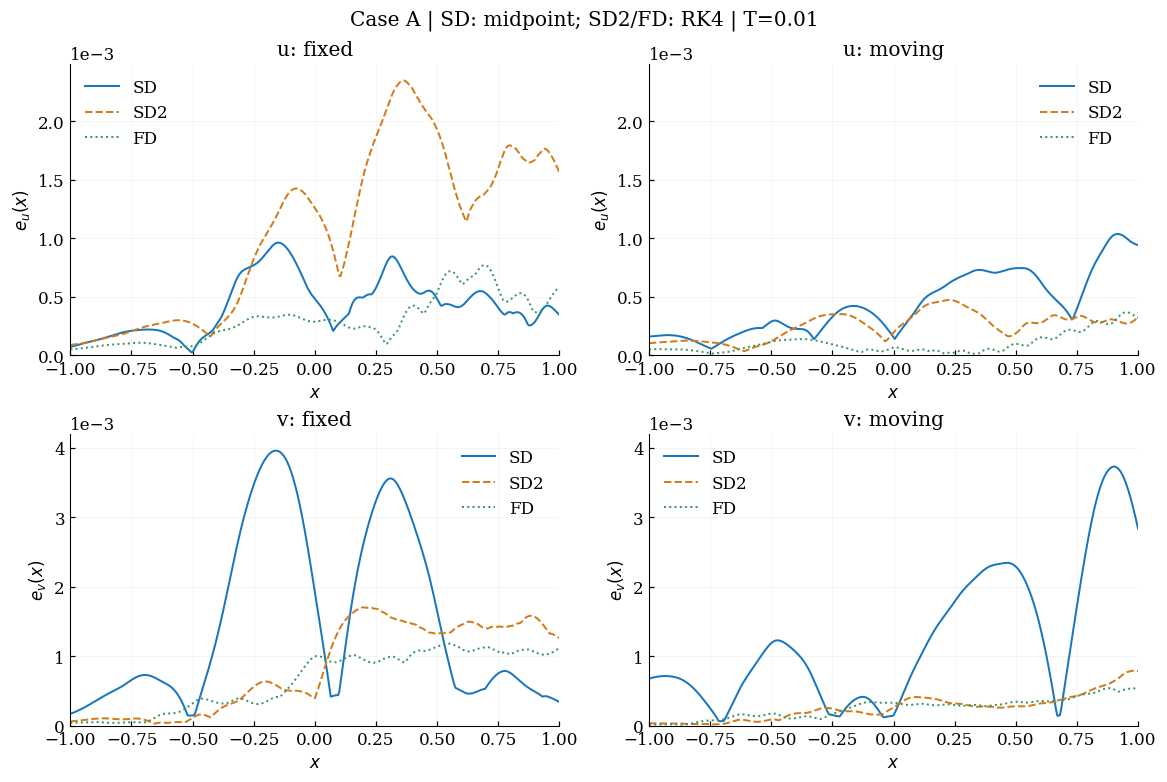

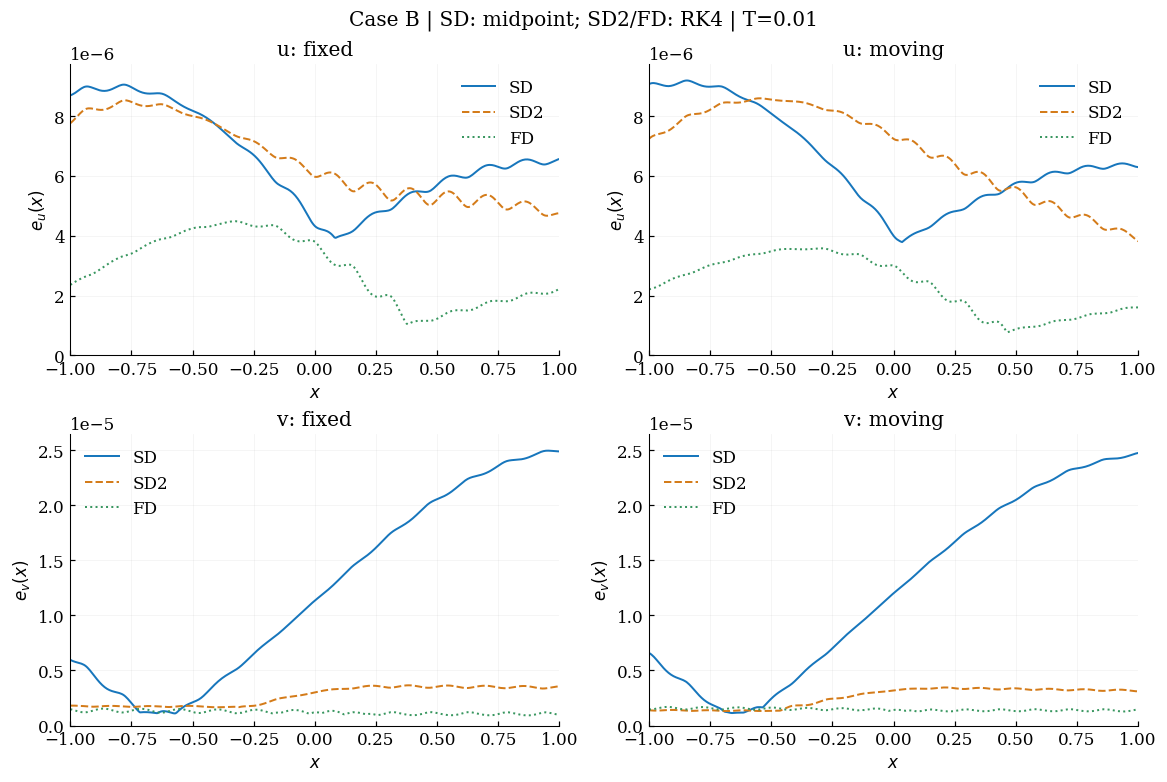

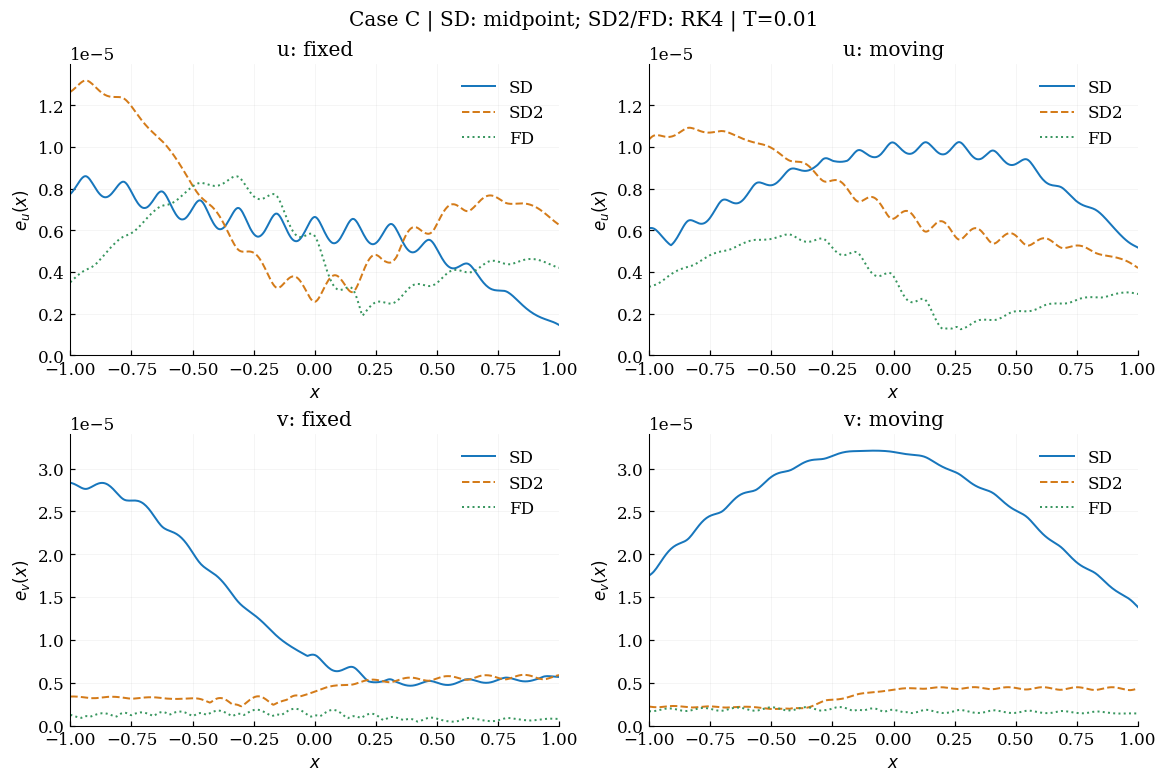

In [16]:
for case in CASES:
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7), layout='constrained')
    for i, field in enumerate(('u', 'v')):
        upper = max(results[case, model, PRIMARY[model], mesh]['errors'][field][:,
            (results[case, model, PRIMARY[model], mesh]['x'] >= -1) &
            (results[case, model, PRIMARY[model], mesh]['x'] <= 1)].max()
            for model in MODELS for mesh in ('fixed', 'moving'))
        for j, mesh in enumerate(('fixed', 'moving')):
            ax = axes[i, j]
            for model, style in zip(MODELS, ('-', '--', ':')):
                r = results[case, model, PRIMARY[model], mesh]
                take = (r['x'] >= -1) & (r['x'] <= 1)
                curve = r['errors'][field].max(axis=0)
                ax.plot(r['x'][take], curve[take], color=COLORS[model], ls=style,
                        lw=1.3, label=model)
            ax.set(xlabel='$x$', ylabel=f'$e_{field}(x)$', xlim=(-1, 1),
                   ylim=(0, upper*1.06), title=f'{field}: {mesh}')
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
            ax.grid(alpha=.16, lw=.5)
            ax.legend(frameon=False)
    fig.suptitle(f'Case {case} | SD: midpoint; SD2/FD: RK4 | T={CONFIG["T"]:g}')
    plt.show()

## 8　结果

配对表给出空间方案的最小误差与动网格相对固定网格的误差比；比值小于 1 表示该场误差降低。

In [17]:
for case in CASES:
    best_u = space_table.loc[(case, 'u')].idxmin()
    best_v = space_table.loc[(case, 'v')].idxmin()
    print(f'算例 {case}：固定网格下，u / v 的最小误差方案为 {best_u} / {best_v}。')
mesh_ratios = mesh_table['moving']/mesh_table['fixed']
ratio_table = mesh_ratios.unstack('场').rename(columns={'u': 'u 动格/固定', 'v': 'v 动格/固定'})
display(ratio_table.style.format('{:.3f}'))
sd_orders = [r['观测阶'] for r in order_rows if r['方案'] == 'SD']
print(f'SD 隐式中点的时间观测阶为 {min(sd_orders):.3f}–{max(sd_orders):.3f}。')
print(f'全部 {len(results)} 组主试验到达 T={CONFIG["T"]:g}；'
      f'评价区间内的初始物理场最大节点差为 {max(r["initial_error"] for r in results.values()):.3e}。')

算例 A：固定网格下，u / v 的最小误差方案为 FD / FD。
算例 B：固定网格下，u / v 的最小误差方案为 FD / FD。
算例 C：固定网格下，u / v 的最小误差方案为 FD / FD。


SD 隐式中点的时间观测阶为 1.979–2.000。
全部 24 组主试验到达 T=0.01；评价区间内的初始物理场最大节点差为 1.064e-12。


参考资料：H.-H. Sheng and G.-F. Yu, *Solitons, breathers and rational solutions for a (2+1)-dimensional dispersive long wave system*, Physica D 432 (2022), 133140。